## Quick sort implementation with random pivot selection

In [22]:
import random

def partition(arr, low, high):#puts 1 pivot in its correct sorted place & returns its index
    ipivot = random.randint(low, high)
    arr[ipivot], arr[high] = arr[high], arr[ipivot]
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1


def quick_sort(arr, low, high):
    if low < high:
        ipivot = partition(arr, low, high)
        quick_sort(arr, low, ipivot - 1)
        quick_sort(arr, ipivot + 1, high)

## Find the Kth smallest element in an array using quick select algorithm

In [23]:
def kth_smallest_element(arr, low, high, K):
    if low <= high:
        ipivot = partition(arr, low, high)
        if ipivot + 1 == K:
            return arr[ipivot]
        elif ipivot + 1 > K:
            return kth_smallest_element(arr, low, ipivot - 1, K)
        else:
            return kth_smallest_element(arr, ipivot + 1, high, K)

## Testing the previous function manually

In [24]:
arr2=[7,6,5,4,3,2,1,9,8]
print(kth_smallest_element(arr2, 0, len(arr2) - 1,1))
print(kth_smallest_element(arr2, 0, len(arr2) - 1,2))
print(kth_smallest_element(arr2, 0, len(arr2) - 1,3))
print(kth_smallest_element(arr2, 0, len(arr2) - 1,8))

1
2
3
8


## Implementation of Heap sort

In [25]:
def max_heapify(arr,size,iparent):#turns only 1 subtree into a heap
    ileftch = 2 * iparent + 1
    irightch = 2 * iparent + 2
    icomp = iparent
    if ileftch < size and arr[ileftch] > arr[icomp]:
        icomp = ileftch
    if irightch < size and arr[irightch] > arr[icomp]:  # if there is a right child,100% there was a left child
        icomp = irightch
    if icomp != iparent:
        arr[iparent], arr[icomp] = arr[icomp], arr[iparent]
        max_heapify(arr,size,icomp)
        
def build_max_heap(arr):#turn the whole array into a heap
#used only in the 1st cycle
    size=len(arr)
    iparent=size//2 -1
    while iparent >= 0:
        max_heapify(arr,size,iparent)
        iparent-=1

#THE MAIN FN,use the other fns to make max heap then use it to sort the array
def heapsort(arr):
    size=len(arr)
    build_max_heap(arr)
    for i in range(size-1):
        arr[0],arr[size-1]=arr[size-1],arr[0]
        size-=1
        max_heapify(arr,size,0)
    return arr

## Implementation of Merge Sort

In [26]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)


def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result += left[i:]
    result += right[j:]

    return result

### Implementation of selection sort

In [27]:
def selection_sort(arr):
    n=len(arr)
    for i in range (n-1):
        minNum=arr[i]
        minindex=i
        for j in range (i+1,n):
            if arr[j]<minNum:
                minindex=j
                minNum =arr[j]
        arr[i], arr[minindex] = arr[minindex], arr[i]
    return arr

## Hybrid Merge + Selection sort

In [28]:
def hybrid_merge_sort(arr, threshold):
    if len(arr) <= threshold:
        return selection_sort(arr)
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = hybrid_merge_sort(arr[:mid], threshold)
    right = hybrid_merge_sort(arr[mid:], threshold)
    return merge(left, right)

### Implementation of insertion sort

In [29]:
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

### Implementation of Bubble sort (with optimization)

In [30]:
def bubble_sort_optimized(arr):
    n = len(arr)
    for i in range(n) : 
        is_already_sorted = True
        for j in range(n-i-1):
            if(arr[j]>arr[j+1]):
                arr[j],arr[j+1] = arr[j+1],arr[j]
                is_already_sorted = False
        if (is_already_sorted  == True ):
            break
    return arr 

### Implementation of bubble sort (with no optimization)

In [31]:
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(n-1-i):
            if(arr[j]>arr[j+1]):
                arr[j],arr[j+1] = arr[j+1],arr[j]
    return arr

## Testing the previous Algorithms maually

In [32]:
arr1 = [1,2,3,4,5,6,7] # sorted array
arr2 = [4,3,5,6,1,2,7] # random array
arr3 = [7,6,5,4,3,2,1] # reverse sorted
arr = [arr1, arr2, arr3]

for x in arr:
    print("Bubble:", bubble_sort(x.copy()))
    print("Bubble Optimized:", bubble_sort_optimized(x.copy()))
    print("Selection:", selection_sort(x.copy()))
    print("Insertion:", insertion_sort(x.copy()))
    print("Merge:", merge_sort(x.copy()))
    q = x.copy()
    quick_sort(q, 0, len(q) - 1)
    print("Quick:", q)
    print("Heap:", heapsort(x.copy()))
    print("Hybrid Merge:", hybrid_merge_sort(x.copy(), threshold=10))
    print("-" * 20)

Bubble: [1, 2, 3, 4, 5, 6, 7]
Bubble Optimized: [1, 2, 3, 4, 5, 6, 7]
Selection: [1, 2, 3, 4, 5, 6, 7]
Insertion: [1, 2, 3, 4, 5, 6, 7]
Merge: [1, 2, 3, 4, 5, 6, 7]
Quick: [1, 2, 3, 4, 5, 6, 7]
Heap: [1, 2, 3, 4, 5, 6, 7]
Hybrid Merge: [1, 2, 3, 4, 5, 6, 7]
--------------------
Bubble: [1, 2, 3, 4, 5, 6, 7]
Bubble Optimized: [1, 2, 3, 4, 5, 6, 7]
Selection: [1, 2, 3, 4, 5, 6, 7]
Insertion: [1, 2, 3, 4, 5, 6, 7]
Merge: [1, 2, 3, 4, 5, 6, 7]
Quick: [1, 2, 3, 4, 5, 6, 7]
Heap: [1, 2, 3, 4, 5, 6, 7]
Hybrid Merge: [1, 2, 3, 4, 5, 6, 7]
--------------------
Bubble: [1, 2, 3, 4, 5, 6, 7]
Bubble Optimized: [1, 2, 3, 4, 5, 6, 7]
Selection: [1, 2, 3, 4, 5, 6, 7]
Insertion: [1, 2, 3, 4, 5, 6, 7]
Merge: [1, 2, 3, 4, 5, 6, 7]
Quick: [1, 2, 3, 4, 5, 6, 7]
Heap: [1, 2, 3, 4, 5, 6, 7]
Hybrid Merge: [1, 2, 3, 4, 5, 6, 7]
--------------------


## Making comparison in case of random and sorted input array 

In [33]:
import time
import random
import matplotlib.pyplot as plt

arr_random = [random.randint(1, 10000) for _ in range(10000)]
arr_sorted = list(range(0, 10000))
times = {}

def measure_time(func, arr, *args):
    arr_copy = arr.copy()
    start = time.perf_counter()
    result = func(arr_copy, *args) 
    end = time.perf_counter()
    return end - start

# Bubble sort
times['Bubble Random']= measure_time(bubble_sort, arr_random)
times['Bubble Optimized Random']= measure_time(bubble_sort_optimized, arr_random)
times['Bubble Sorted']= measure_time(bubble_sort, arr_sorted)
times['Bubble Optimized Sorted'] = measure_time(bubble_sort_optimized, arr_sorted)
# Merge sort
times['Merge Random'] = measure_time(merge_sort, arr_random)
times['Merge Sorted'] = measure_time(merge_sort, arr_sorted)
# Quick sort 
def quick_sort_wrapper(arr):
    quick_sort(arr, 0, len(arr)-1)
    return arr
times['Quick Random'] = measure_time(quick_sort_wrapper, arr_random)
times['Quick Sorted'] = measure_time(quick_sort_wrapper, arr_sorted)
# Heap sort
times['Heap Random'] = measure_time(heapsort, arr_random)
times['Heap Sorted'] = measure_time(heapsort, arr_sorted)
# Hybrid merge sort with threshold=6
times['Hybrid Random'] = measure_time(hybrid_merge_sort, arr_random, 6)
times['Hybrid Sorted'] = measure_time(hybrid_merge_sort, arr_sorted, 6)

for k, v in times.items():
    print(f"{k}: {v:.5f} seconds")

Bubble Random: 4.71211 seconds
Bubble Optimized Random: 4.65552 seconds
Bubble Sorted: 2.76408 seconds
Bubble Optimized Sorted: 0.00056 seconds
Merge Random: 0.02536 seconds
Merge Sorted: 0.01636 seconds
Quick Random: 0.01527 seconds
Quick Sorted: 0.01547 seconds
Heap Random: 0.03089 seconds
Heap Sorted: 0.03190 seconds
Hybrid Random: 0.01905 seconds
Hybrid Sorted: 0.01186 seconds


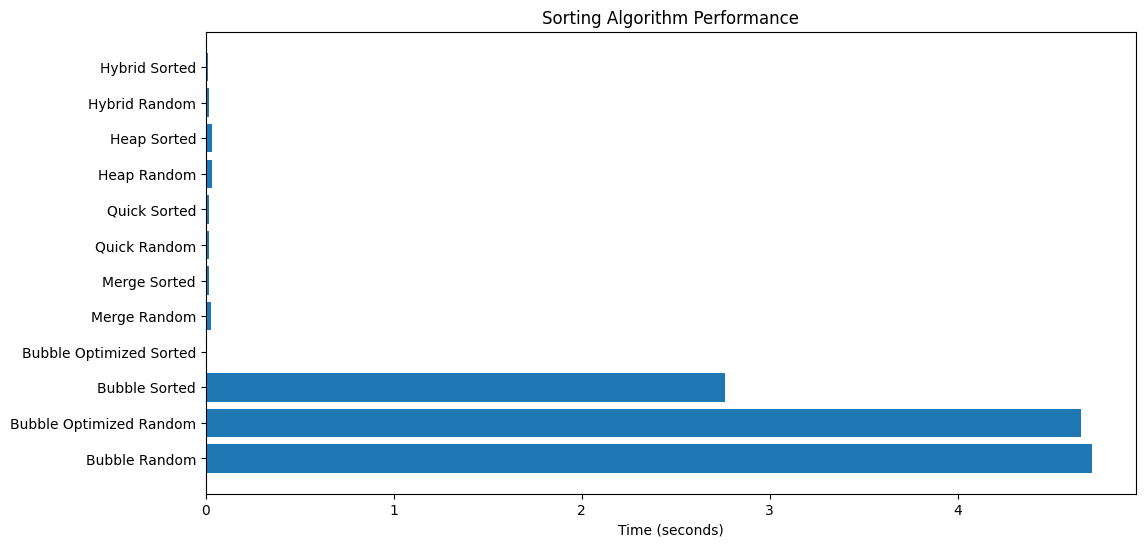

In [34]:
labels = list(times.keys())
values = list(times.values())
plt.figure(figsize=(12,6))
plt.barh(labels, values)
plt.xlabel("Time (seconds)")
plt.title("Sorting Algorithm Performance")
plt.show()

## Comparison between sorting algorithms while changing the array size

In [ ]:
import random
import time
# Functon to generate an array of given size with random integers
def generate_array_of_size(size):
    return [random.randint(-10000000, 10000000) for _ in range(size)]

# Function to run all sorting algorithms on a given array and return their execution times
def run_all_sorting_algorithms(arr, hybrid_threshold=10):
    times = []
    
    # Bubble sort optimized
    arr_copy = arr.copy()
    t1 = time.perf_counter()
    bubble_sort_optimized(arr_copy)
    t2 = time.perf_counter()
    times.append(t2-t1)

    # Insertion sort
    arr_copy = arr.copy()
    t1 = time.perf_counter()
    insertion_sort(arr_copy)
    t2 = time.perf_counter()
    times.append(t2-t1)

    # Selection sort
    arr_copy = arr.copy()
    t1 = time.perf_counter()
    selection_sort(arr_copy)
    t2 = time.perf_counter()
    times.append(t2-t1)

    # Merge sort
    arr_copy = arr.copy()
    t1 = time.perf_counter()
    merge_sort(arr_copy)
    t2 = time.perf_counter()
    times.append(t2-t1)

    # Quick sort
    arr_copy = arr.copy()
    t1 = time.perf_counter()
    quick_sort_wrapper(arr_copy)
    t2 = time.perf_counter()
    times.append(t2-t1)

    # Heap sort
    arr_copy = arr.copy()
    t1 = time.perf_counter()
    heapsort(arr_copy)
    t2 = time.perf_counter()
    times.append(t2-t1)


    return times


all_times = []
array_sizes = []
num_tests = 5

for _ in range(num_tests):
    size = int(input("Enter array size: "))
    array_sizes.append(size)
    arr = generate_array_of_size(size)
    all_times.append(run_all_sorting_algorithms(arr))


algorithm_names = [
    "Bubble Optimized", "Insertion", "Selection",
    "Merge", "Quick", "Heap"]

for i, size in enumerate(array_sizes):
    print(f"\nArray size: {size}")
    for alg, t in zip(algorithm_names, all_times[i]):
        print(f"{alg}: {t:.5f} seconds")


Array size: 1000
Bubble Optimized: 0.04317 seconds
Insertion: 0.02008 seconds
Selection: 0.01734 seconds
Merge: 0.00189 seconds
Quick: 0.00109 seconds
Heap: 0.00211 seconds

Array size: 5000
Bubble Optimized: 1.11558 seconds
Insertion: 0.50511 seconds
Selection: 0.43029 seconds
Merge: 0.01127 seconds
Quick: 0.00739 seconds
Heap: 0.01363 seconds

Array size: 10000
Bubble Optimized: 4.52316 seconds
Insertion: 2.06023 seconds
Selection: 1.71325 seconds
Merge: 0.02382 seconds
Quick: 0.01470 seconds
Heap: 0.03083 seconds

Array size: 25000
Bubble Optimized: 29.33726 seconds
Insertion: 13.06558 seconds
Selection: 10.92709 seconds
Merge: 0.06743 seconds
Quick: 0.04032 seconds
Heap: 0.08924 seconds

Array size: 60000
Bubble Optimized: 170.37460 seconds
Insertion: 74.04358 seconds
Selection: 63.51490 seconds
Merge: 0.16643 seconds
Quick: 0.10385 seconds
Heap: 0.22751 seconds


## making plot to visualize the comparison


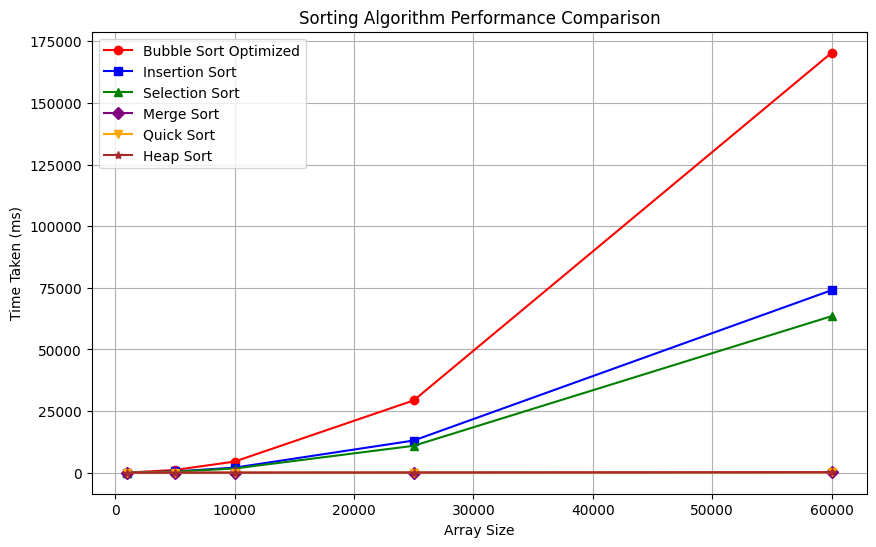

In [35]:
import matplotlib.pyplot as plt

# Convert all times to milliseconds
all_times_ms = [[t * 1000 for t in sublist] for sublist in all_times]

# Separate times for each algorithm
bubble_times = [t[0] for t in all_times_ms]
insertion_times = [t[1] for t in all_times_ms]
selection_times = [t[2] for t in all_times_ms]
merge_times = [t[3] for t in all_times_ms]
quick_times = [t[4] for t in all_times_ms]
heap_times = [t[5] for t in all_times_ms]

# Plot all algorithms
plt.figure(figsize=(10, 6))
plt.plot(array_sizes, bubble_times, marker='o', color='red', label='Bubble Sort Optimized')
plt.plot(array_sizes, insertion_times, marker='s', color='blue', label='Insertion Sort')
plt.plot(array_sizes, selection_times, marker='^', color='green', label='Selection Sort')
plt.plot(array_sizes, merge_times, marker='D', color='purple', label='Merge Sort')
plt.plot(array_sizes, quick_times, marker='v', color='orange', label='Quick Sort')
plt.plot(array_sizes, heap_times, marker='*', color='brown', label='Heap Sort')
plt.xlabel("Array Size")
plt.ylabel("Time Taken (ms)")
plt.title("Sorting Algorithm Performance Comparison")
plt.legend()
plt.grid(True)
plt.show()

### Conclusion:

From the performance comparison of different sorting algorithms, we can observe the following:

1. **Bubble Sort (Optimized), Insertion Sort, and Selection Sort** have **very high time complexity** for large arrays. Their performance degrades significantly as the array size increases, demonstrating their **O(n²)** behavior. Among them, Bubble Sort is the slowest for large arrays.

2. **Merge Sort, Quick Sort, and Heap Sort** perform significantly better on large arrays. These algorithms exhibit **O(n log n)** time complexity, which allows them to handle larger datasets efficiently. Their execution time grows much more slowly compared to the simple quadratic algorithms.

3. **Scalability difference** is very clear: while Bubble, Insertion, and Selection Sort take tens or hundreds of seconds for arrays of size 60,000, the advanced algorithms (Merge, Quick, Heap) complete almost instantly, showing the importance of choosing the right sorting algorithm for large datasets.

**Conclusion:** For small datasets, simple algorithms like Insertion or Selection Sort may be acceptable. For medium to large datasets, **Merge Sort, Quick Sort, and Heap Sort are highly recommended** due to their superior efficiency and scalability.

---


## Printing the time in each case in ms

In [36]:
import pandas as pd
data = {
    f'Array Size {size}': [bubble_times[i], insertion_times[i], selection_times[i],
                           merge_times[i], quick_times[i], heap_times[i]]
    for i, size in enumerate(array_sizes)}
index = ['Bubble Sort Optimized', 'Insertion Sort', 'Selection Sort',
         'Merge Sort', 'Quick Sort', 'Heap Sort']

df = pd.DataFrame(data, index=index)
display(df)

,Array Size 1000,Array Size 5000,Array Size 10000,Array Size 25000,Array Size 60000
Bubble Sort Optimized,43.1680,1115.5786,4523.1611,29337.2581,170374.6021
Insertion Sort,20.0766,505.1054,2060.2332,13065.5799,74043.5817
Selection Sort,17.3362,430.2850,1713.2547,10927.0917,63514.8973
Merge Sort,1.8856,11.2668,23.8166,67.4306,166.4286
Quick Sort,1.0872,7.3879,14.7039,40.3164,103.8525
Heap Sort,2.1112,13.6290,30.8331,89.2445,227.5150
